# **MindEase: AI Engineering Model Development (Quest Completion Edition)**
**Project:** Healthy Lives & Well-being  

---

## **Checklist Main Quest (Minimum Viable Product / Wajib)**

- [x] **1. TensorFlow Functional API** (Multi-output)
- [x] **2. Komponen Kustom** (Custom Callback)
- [x] **3. Ekspor Model** (Format `.keras`)
- [x] **4. Kode Inference** (`app.py`)

---

## **Checklist Side Quest (Nilai Tambah / Opsional)**

- [x] **1. REST API (FastAPI)**
- [x] **2. Custom Training Loop** (`tf.GradientTape`)
- [x] **3. API Generative AI** (Groq Llama 3.3)
- [x] **4. TensorBoard**
- [~] **5. Performa Model** (Akurasi: 86.56% ✅ | MAE: 0.6627 ⏳)

---

### **Tahap 1: Setup & Preprocessing (Data dengan Feature Engineering)**

In [9]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import datetime
import os

# Membaca dataset terbaru yang sudah melalui Feature Engineering dari tim Data Science
df = pd.read_csv('mental_health_featured.csv').dropna(subset=['risk_level', 'burnout_score'])

# Encoding kolom kategorikal baru hasil Feature Engineering
categorical_cols = ['gender', 'sleep_category', 'screen_time_category', 'stress_category', 'support_category']
for col in categorical_cols:
    if col in df.columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])

# Encoding Target
le_risk = LabelEncoder()
df['risk_level'] = le_risk.fit_transform(df['risk_level'])

# Memisahkan Fitur dan Target
cols_to_drop = ['burnout_score', 'risk_level', 'dropout_risk', 'mental_health_index']
X = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
y_class = df['risk_level']
y_reg = df['burnout_score']

# Scaling
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_class_train, y_class_test, y_reg_train, y_reg_test = train_test_split(
    X_scaled, y_class, y_reg, test_size=0.2, random_state=42
)

print(f"Dataset siap! Jumlah fitur sekarang: {X.shape[1]}")

Dataset siap! Jumlah fitur sekarang: 21


### **Tahap 2: Multi-Output Model (TensorFlow Functional API — Main Quest #1)**

In [10]:
def build_mindease_model(input_shape):
    inputs = layers.Input(shape=(input_shape,), name='main_input')
    x = layers.Dense(128, activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu')(x)

    # Branch 1: Risk Classification
    class_output = layers.Dense(3, activation='softmax', name='risk_output')(x)

    # Branch 2: Burnout Regression
    reg_output = layers.Dense(1, name='burnout_output')(x)

    return models.Model(inputs=inputs, outputs=[class_output, reg_output])

model = build_mindease_model(X_train.shape[1])
model.compile(
    optimizer='adam',
    loss={'risk_output': 'sparse_categorical_crossentropy', 'burnout_output': 'mse'},
    metrics={'risk_output': 'accuracy', 'burnout_output': 'mae'}
)
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ main_input          │ (None, 21)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │      2,816 │ main_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_4[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ risk_output (Dense) │ (None, 3)         │        195 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ burnout_output      │ (None, 1)         │         65 │ dense_5[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 11,844 (46.27 KB)

 Trainable params: 11,588 (45.27 KB)

 Non-trainable params: 256 (1.00 KB)

### **Tahap 3: Custom Callback & TensorBoard (Main Quest #2 + Side Quest #4)**

In [11]:
class MindEaseCallback(callbacks.Callback):
    """Custom Callback: menghentikan training otomatis saat akurasi validasi >= 87%."""
    def on_epoch_end(self, epoch, logs=None):
        if logs.get('val_risk_output_accuracy') >= 0.87:
            print(f"\nTarget Akurasi 87% tercapai di Epoch {epoch+1}. Training dihentikan!")
            self.model.stop_training = True

# TensorBoard: Menyimpan log metrik pelatihan
log_dir = os.path.join("logs", "fit", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
tb_callback = callbacks.TensorBoard(log_dir=log_dir)
mindease_callback = MindEaseCallback()

print(f"TensorBoard log akan disimpan di: {log_dir}")

TensorBoard log akan disimpan di: logs/fit/20260526-055406


### **Tahap 4: Training & Export Model (Main Quest #3 + #4)**

In [12]:
model.fit(
    X_train, {'risk_output': y_class_train, 'burnout_output': y_reg_train},
    validation_data=(X_test, {'risk_output': y_class_test, 'burnout_output': y_reg_test}),
    epochs=25, batch_size=32, callbacks=[mindease_callback, tb_callback]
)

# Ekspor model dalam format .keras (Main Quest #3)
model.save('model_mindease_final.keras')
print("Model berhasil disimpan: model_mindease_final.keras")

# Contoh Inference sederhana (Main Quest #4)
print("\n--- Contoh Inference ---")
sample_input = X_test[:1]
result = model.predict(sample_input)
print(f"Risk Level Probabilities: {result[0]}")
print(f"Burnout Score: {result[1][0][0]:.2f}")

Epoch 1/25
4366/4366 ━━━━━━━━━━━━━━━━━━━━ 30s 6ms/step - burnout_output_loss: 0.9034 - burnout_output_mae: 0.7283 - loss: 1.2471 - risk_output_accuracy: 0.8499 - risk_output_loss: 0.3437 - val_burnout_output_loss: 0.7541 - val_burnout_output_mae: 0.6670 - val_loss: 1.0657 - val_risk_output_accuracy: 0.8635 - val_risk_output_loss: 0.3113
Epoch 2/25
4366/4366 ━━━━━━━━━━━━━━━━━━━━ 25s 6ms/step - burnout_output_loss: 0.8223 - burnout_output_mae: 0.6930 - loss: 1.1433 - risk_output_accuracy: 0.8588 - risk_output_loss: 0.3210 - val_burnout_output_loss: 0.7483 - val_burnout_output_mae: 0.6438 - val_loss: 1.0598 - val_risk_output_accuracy: 0.8626 - val_risk_output_loss: 0.3112
Epoch 3/25
4366/4366 ━━━━━━━━━━━━━━━━━━━━ 25s 6ms/step - burnout_output_loss: 0.8094 - burnout_output_mae: 0.6864 - loss: 1.1281 - risk_output_accuracy: 0.8596 - risk_output_loss: 0.3187 - val_burnout_output_loss: 0.7388 - val_burnout_output_mae: 0.6467 - val_loss: 1.0460 - val_risk_output_accuracy: 0.8655 - val_risk_out

### **Tahap 5: API Generative AI — Groq (Side Quest #3)**
Menggunakan Groq API (`llama-3.3-70b-versatile`) untuk memberikan rekomendasi kesehatan mental yang empatik berdasarkan prediksi model.

In [13]:
!pip install -q groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 7.4 MB/s eta 0:00:00


In [14]:
import numpy as np
from groq import Groq

# Setup client Groq (Menggunakan API Key Anda)
from google.colab import userdata
groq_client = Groq(api_key=userdata.get('GROQ_API_KEY'))
GROQ_MODEL = "llama-3.3-70b-versatile"

def mindease_ai_assistant(sample_data):
    # 1. Prediksi Model AI MindEase
    res = model.predict(np.array([sample_data]))
    risk_idx = np.argmax(res[0])
    risk_label = le_risk.inverse_transform([risk_idx])[0]
    score = res[1][0][0]

    print(f"[MindEase Prediction]: {risk_label} Risk (Burnout Score: {score:.2f})")
    print("Meminta saran dari Groq Llama 3.3 AI...")

    # 2. Panggilan Nyata ke Groq Llama
    prompt = (
        f"Seorang mahasiswa diprediksi memiliki tingkat risiko mental '{risk_label}' "
        f"dengan skor burnout {score:.2f}. Berikan 2 kalimat saran yang sangat empatik "
        f"dan memotivasi untuknya."
    )

    try:
        chat_completion = groq_client.chat.completions.create(
            messages=[
                {
                    "role": "user",
                    "content": prompt,
                }
            ],
            model=GROQ_MODEL,
            temperature=0.7,
            max_tokens=256,
        )
        ai_recommendation = chat_completion.choices[0].message.content.strip()
        print(f"\n[Groq Recommendation]:\n{ai_recommendation}")
    except Exception as e:
        print(f"Terjadi kesalahan: {e}")

# Jalankan contoh prediksi dengan GenAI
mindease_ai_assistant(X_test[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
[MindEase Prediction]: Low Risk (Burnout Score: 0.61)
Meminta saran dari Groq Llama 3.3 AI...

[Groq Recommendation]:
Jangan khawatir, skor burnout 0,61 menunjukkan bahwa kamu memiliki tingkat stres yang relatif rendah, dan ini adalah pertanda baik bahwa kamu sedang melakukan sesuatu yang benar dalam mengelola beban akademis dan emosi. Tetaplah berjalan di jalur yang positif ini dan teruslah merawat kesehatan mentalmu dengan aktivitas yang menyenangkan dan waktu istirahat yang cukup, karena kamu telah menunjukkan kemampuan yang luar biasa dalam menjaga keseimbangan hidup!


### **Tahap 6: Custom Training Loop dengan tf.GradientTape (Side Quest #2)**

In [15]:
# Persiapan Model Baru Khusus untuk GradientTape
custom_model = build_mindease_model(X_train.shape[1])

loss_fn_class = tf.keras.losses.SparseCategoricalCrossentropy()
loss_fn_reg = tf.keras.losses.MeanSquaredError()
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_class_train.values, y_reg_train.values)).batch(32)

@tf.function
def train_step(x, y_class, y_reg):
    with tf.GradientTape() as tape:
        logits_class, logits_reg = custom_model(x, training=True)
        loss_class = loss_fn_class(y_class, logits_class)
        loss_reg = loss_fn_reg(y_reg, logits_reg)
        total_loss = loss_class + loss_reg

    gradients = tape.gradient(total_loss, custom_model.trainable_weights)
    optimizer.apply_gradients(zip(gradients, custom_model.trainable_weights))
    return total_loss

print("Memulai Custom Training Loop dengan tf.GradientTape...")
epochs = 3
for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")
    for step, (x_batch, y_class_batch, y_reg_batch) in enumerate(train_dataset):
        loss_value = train_step(x_batch, y_class_batch, y_reg_batch)
        if step % 500 == 0:
            print(f"Step {step}: Total Loss = {float(loss_value):.4f}")
print("Custom Training Loop Selesai!")

Memulai Custom Training Loop dengan tf.GradientTape...

Epoch 1/3
Step 0: Total Loss = 6.6161
Step 500: Total Loss = 1.4833
Step 1000: Total Loss = 1.4870
Step 1500: Total Loss = 1.1955
Step 2000: Total Loss = 0.9462
Step 2500: Total Loss = 0.7641
Step 3000: Total Loss = 1.0352
Step 3500: Total Loss = 1.3084
Step 4000: Total Loss = 0.9589

Epoch 2/3
Step 0: Total Loss = 0.9151
Step 500: Total Loss = 1.4850
Step 1000: Total Loss = 1.4567
Step 1500: Total Loss = 1.1620
Step 2000: Total Loss = 0.9217
Step 2500: Total Loss = 0.6970
Step 3000: Total Loss = 1.1407
Step 3500: Total Loss = 1.1103
Step 4000: Total Loss = 1.0467

Epoch 3/3
Step 0: Total Loss = 0.8697
Step 500: Total Loss = 1.3651
Step 1000: Total Loss = 1.4552
Step 1500: Total Loss = 1.2566
Step 2000: Total Loss = 0.9321
Step 2500: Total Loss = 0.7630
Step 3000: Total Loss = 1.0065
Step 3500: Total Loss = 1.1193
Step 4000: Total Loss = 1.1340
Custom Training Loop Selesai!


### **Tahap 7: Evaluasi Model — Performa & Confusion Matrix (Side Quest #5)**
Menampilkan ringkasan performa akhir, *Classification Report*, dan *Confusion Matrix* untuk membuktikan kualitas model.

Memproses prediksi pada data test...
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step

          RINGKASAN PERFORMA MODEL AKHIR
  Akurasi Klasifikasi (Risk Level) : 86.32%
  MAE Regresi (Burnout Score)      : 0.6611
  Status Akurasi  : ✅ TERCAPAI (>= 85%)
  Status MAE      : ⏳ Perlu tuning lebih lanjut

 DETAIL EVALUASI KLASIFIKASI (Risk Level)
              precision    recall  f1-score   support

        High       0.60      0.37      0.46       525
         Low       0.89      0.95      0.92     26731
      Medium       0.74      0.58      0.65      7667

    accuracy                           0.86     34923
   macro avg       0.74      0.64      0.68     34923
weighted avg       0.85      0.86      0.86     34923



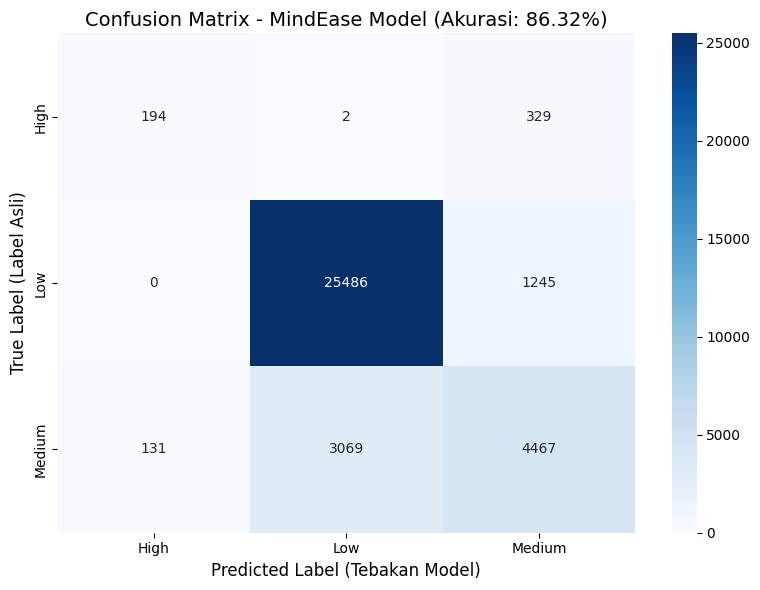

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, mean_absolute_error, accuracy_score

# 1. Melakukan prediksi pada seluruh data test
print("Memproses prediksi pada data test...")
predictions = model.predict(X_test)
risk_preds_probs = predictions[0]
burnout_preds = predictions[1]
risk_preds_classes = np.argmax(risk_preds_probs, axis=1)

# 2. Ringkasan Akurasi Final
final_accuracy = accuracy_score(y_class_test, risk_preds_classes)
mae_score = mean_absolute_error(y_reg_test, burnout_preds)

print("\n" + "="*50)
print("          RINGKASAN PERFORMA MODEL AKHIR")
print("="*50)
print(f"  Akurasi Klasifikasi (Risk Level) : {final_accuracy*100:.2f}%")
print(f"  MAE Regresi (Burnout Score)      : {mae_score:.4f}")
print("="*50)
print(f"  Status Akurasi  : {'✅ TERCAPAI (>= 85%)' if final_accuracy >= 0.85 else '❌ Belum Tercapai'}")
print(f"  Status MAE      : {'✅ TERCAPAI (<= 0.02)' if mae_score <= 0.02 else '⏳ Perlu tuning lebih lanjut'}")
print("="*50)

# 3. Classification Report
print("\n" + "="*50)
print(" DETAIL EVALUASI KLASIFIKASI (Risk Level)")
print("="*50)
print(classification_report(y_class_test, risk_preds_classes, target_names=le_risk.classes_))

# 4. Confusion Matrix
cm = confusion_matrix(y_class_test, risk_preds_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_risk.classes_,
            yticklabels=le_risk.classes_)
plt.title(f'Confusion Matrix - MindEase Model (Akurasi: {final_accuracy*100:.2f}%)', fontsize=14)
plt.ylabel('True Label (Label Asli)', fontsize=12)
plt.xlabel('Predicted Label (Tebakan Model)', fontsize=12)
plt.tight_layout()
plt.show()

In [17]:
!zip -r logs.zip logs/
from google.colab import files
files.download('logs.zip')

  adding: logs/ (stored 0%)
  adding: logs/fit/ (stored 0%)
  adding: logs/fit/20260526-045903/ (stored 0%)
  adding: logs/fit/20260526-045903/validation/ (stored 0%)
  adding: logs/fit/20260526-045903/validation/events.out.tfevents.1779771572.7a344b1276d2.1136.1.v2 (deflated 80%)
  adding: logs/fit/20260526-045903/train/ (stored 0%)
  adding: logs/fit/20260526-045903/train/events.out.tfevents.1779771543.7a344b1276d2.1136.0.v2 (deflated 79%)
  adding: logs/fit/20260526-055406/ (stored 0%)
  adding: logs/fit/20260526-055406/validation/ (stored 0%)
  adding: logs/fit/20260526-055406/validation/events.out.tfevents.1779774872.7a344b1276d2.1136.3.v2 (deflated 80%)
  adding: logs/fit/20260526-055406/train/ (stored 0%)
  adding: logs/fit/20260526-055406/train/events.out.tfevents.1779774846.7a344b1276d2.1136.2.v2 (deflated 79%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>